In [2]:
import os
import re
import pickle as pkl
import ast
from collections import Counter
from typing import List, Tuple, Any
from tqdm import tqdm
import time

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import pandas as pd
import numpy as np
import calibration as cal

import torch

from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score

import json
from typing import Optional
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
pal = plt.rcParams['axes.prop_cycle'].by_key()['color']


In [3]:
from llm_unsupervised_conf.metrics import *
from llm_unsupervised_conf.math_utils import stack_embeddings
from llm_unsupervised_conf.calibration import fit_predict_prob_models
from llm_unsupervised_conf.plots import plot_reliability, plot_avg_and_worstcase_by_method, plot_method_comparisons
from llm_unsupervised_conf.utils import qa_correct

In [4]:
def _get_method_stats(dm_df, method, dataset):

    method_df = dm_df[dm_df["method"] == method]

    if dataset in ["trivia_qa", "webq"]:

        correct = np.fromiter(
            (qa_correct(a, gts) for a, gts in zip(method_df["final_answer"], method_df["ground_truth"])),
            dtype=np.int64,
            count=len(method_df),
        )
        
    elif dataset == "sciq":

        correct = np.fromiter(
            (qa_correct(a, [gts]) for a, gts in zip(method_df["final_answer"], method_df["ground_truth"])),
            dtype=np.int64,
            count=len(method_df),
        )
        
    else:
        correct = (method_df["final_answer"].fillna("") == method_df["ground_truth"].fillna("")).astype(int).to_numpy(dtype=np.int64)

    return correct, method_df["final_confidence"], method_df["baseline_confidence"], method_df["baseline_correct"]

In [5]:
METHODS_MAP = {
    "vc": "Verbal Conf.",
    "lp": "Token Probs.",
    "ours": "Ours",
    "base_gpt": "Base Model",
    "baseline": "Base Model"
}

def plot_reliability(
    correct,
    all_probs,
    n_bins=12,
    binning="quantile",
    figsize=None,            # if None, auto based on #panels
    suptitle="Reliability diagrams",
    subtitle="Ours",
    show_counts=False,
    limit_axes=False,
):
    """
    Reliability diagrams using sklearn calibration_curve.

    Panels:
      - Self-consistency (con_scores in [0,1])
      - exp(avg_logprobs)
      - exp(ans_logprobs)
      - (optional) verbal_conf in [0,1]
    """
    # dm_prob  = np.asarray(dm_probs, dtype=float)
    # our_prob = np.asarray(pred_probs, dtype=float)

    panels = []
    for k, v in all_probs.items():
        panels.append(
            (k, v[0], v[1], v[2])
        )

    n_panels = len(panels)
    if figsize is None:
        figsize = (3.5 * n_panels, 3.0)

    fig, axes = plt.subplots(1, n_panels, figsize=figsize, constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    ax_min = 1.0

    for ax, (title, p, c, ece) in zip(axes, panels):
        p = np.clip(p, 0.0, 1.0)
        prob_true, prob_pred = calibration_curve(c, p, n_bins=n_bins, strategy=binning)
    
        # Plot curve + y=x
        ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
        ax.plot(prob_pred, prob_true, marker="o", linewidth=2)
        
        ax.set_title(f"{METHODS_MAP[title]} (ECE={round(ece, 3)})", fontsize=14)
        # ax.set_xlim(0.2, 1.02)
        # ax.set_ylim(0.2, 1.02)
        
        ax.set_xlabel("Confidence", fontsize=14)
        ax.set_ylabel("Accuracy", fontsize=14)

        ax_min = min(ax_min, np.min(prob_pred))
        ax_min = min(ax_min, np.min(prob_true))

    scale_factor = 0.95
    for ax, _ in zip(axes, panels):

        ax.set_xlim(ax_min*scale_factor, 1.02)
        ax.set_ylim(ax_min*scale_factor, 1.02)


    fig.suptitle(suptitle, fontsize=14, y=1.15)
    plt.show()


In [6]:
def get_output(
    cal_model_name, 
    gpt_model_name="gpt-4o-mini", 
    dataset="sciq", 
    random_state=10,
    n_bins=12,
    methods = ["vc", "lp", "ours"],
    our_method = "split_isotonic_on_ridge_nrt"
):
    

    cal_model_name_clean = cal_model_name.split("/")[-1].replace("-", "_")

    test_df = pd.read_csv(f"../outputs/sim_decisions/sim_{cal_model_name_clean}_{gpt_model_name}_{dataset}_{our_method}_{random_state}_test_df.csv")
    dm_df = pd.read_csv(f"../outputs/sim_decisions/sim_{cal_model_name_clean}_{gpt_model_name}_{dataset}_{our_method}_{random_state}_dm_df.csv")
    dm_df = dm_df.sort_values(by="id")

    baseline_df_path = f"../outputs/_baselines_openai/{gpt_model_name}/{dataset}/baseline_{gpt_model_name}.csv"
    baseline_dm_df = pd.read_csv(baseline_df_path)

    # 1) take only what you need from baseline, and rename to avoid confusion
    baseline_conf = (
        baseline_dm_df[["id", "confidence", "correct"]]
        .rename(columns={"confidence": "baseline_confidence"})
        .rename(columns={"correct": "baseline_correct"})
    )
    
    # 2) left join so every dm_df row stays
    dm_df = dm_df.merge(baseline_conf, on="id", how="left")

    rows = []
    columns = ["Method", "ECE1", "ECE2", "MCE", "NLL", "Brier", "AUROC", "DM_acc", "OG_acc"]

    all_probs = {}
    
    for method in methods:

        correct, pred_probs, base_probs, base_correct = _get_method_stats(dm_df, method, dataset)
        # print("bp", np.mean(base_probs))
        # print("bc", np.mean(base_correct))
        og_correct = dm_df[dm_df["method"] == method]["correct"]

        rows.append([
            method,
            get_ece1(pred_probs, correct, n_bins=n_bins),
            get_ece2(pred_probs, correct, n_bins=n_bins),
            get_mce(pred_probs, correct, n_bins=n_bins),
            get_nll(pred_probs, correct),
            brier_score_loss(correct, pred_probs),
            roc_auc_score(correct, pred_probs),
            np.mean(correct),
            np.mean(og_correct)
        ])

        all_probs[method] = (pred_probs, correct, get_ece2(pred_probs, correct, n_bins=n_bins))

    all_probs["base_gpt"] = (base_probs, base_correct, get_ece2(base_probs, base_correct, n_bins=n_bins))
    
    plot_reliability(
        correct,
        all_probs,
        n_bins=n_bins,
        suptitle=f"Reliability diagrams for {gpt_model_name} assisted by\n{cal_model_name_clean} (answer/conf) on {dataset}",
        subtitle=method,
    )
    
    exp_df = pd.DataFrame(rows, columns=columns)

    display(
        exp_df[["Method", "ECE1", "ECE2", "MCE", "Brier", "AUROC", "DM_acc", "OG_acc"]]
    )

    exp_df["model"] = model
    exp_df["dataset"] = dataset
        
    return test_df, dm_df, exp_df
        



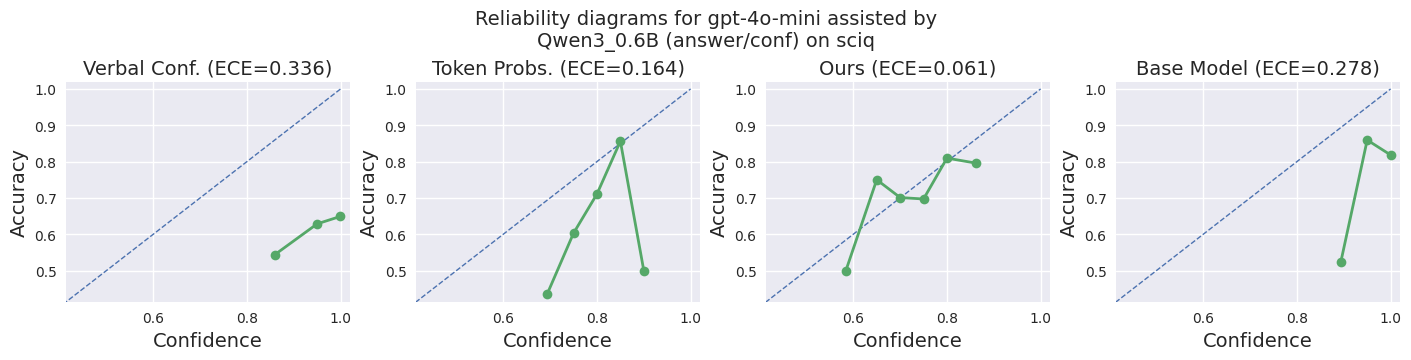

,Method,ECE1,ECE2,MCE,Brier,AUROC,DM_acc,OG_acc
0,vc,0.335464,0.335873,0.350439,0.346580,0.558734,0.611684,0.391753
1,lp,0.133333,0.163504,0.400000,0.232998,0.681805,0.640893,0.391753
2,ours,0.043557,0.060538,0.100000,0.223192,0.632880,0.634021,0.391753


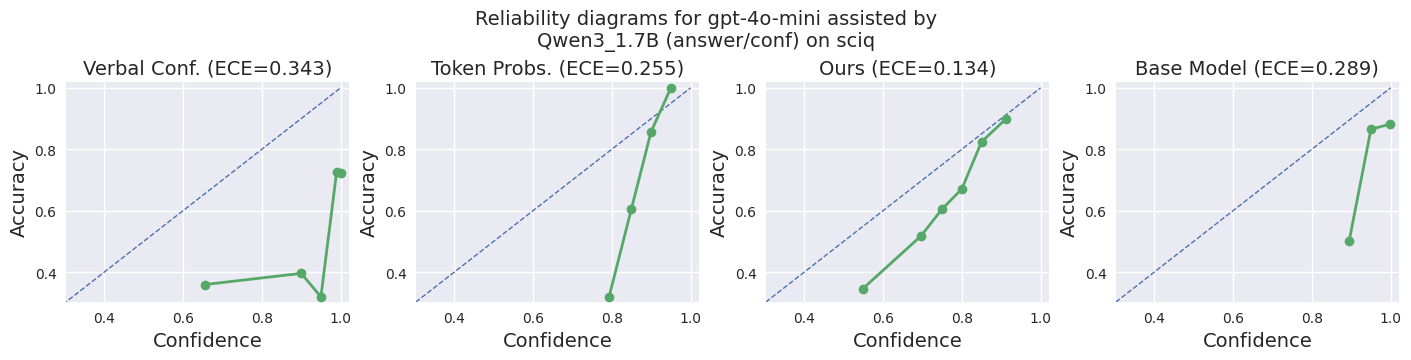

,Method,ECE1,ECE2,MCE,Brier,AUROC,DM_acc,OG_acc
0,vc,0.323633,0.342892,0.630000,0.329831,0.648318,0.631667,0.608333
1,lp,0.217350,0.255322,0.472346,0.266550,0.689718,0.640000,0.608333
2,ours,0.113217,0.133931,0.202564,0.218546,0.705825,0.643333,0.608333


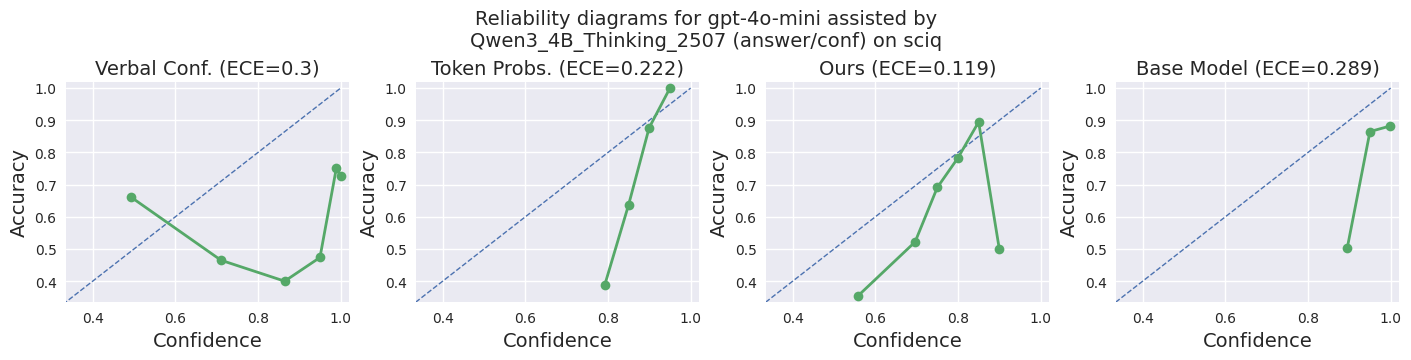

,Method,ECE1,ECE2,MCE,Brier,AUROC,DM_acc,OG_acc
0,vc,0.28390,0.300222,0.476316,0.298758,0.621315,0.653333,0.651667
1,lp,0.18895,0.222191,0.404500,0.248709,0.671900,0.666667,0.651667
2,ours,0.09400,0.119357,0.400000,0.209317,0.709183,0.663333,0.651667


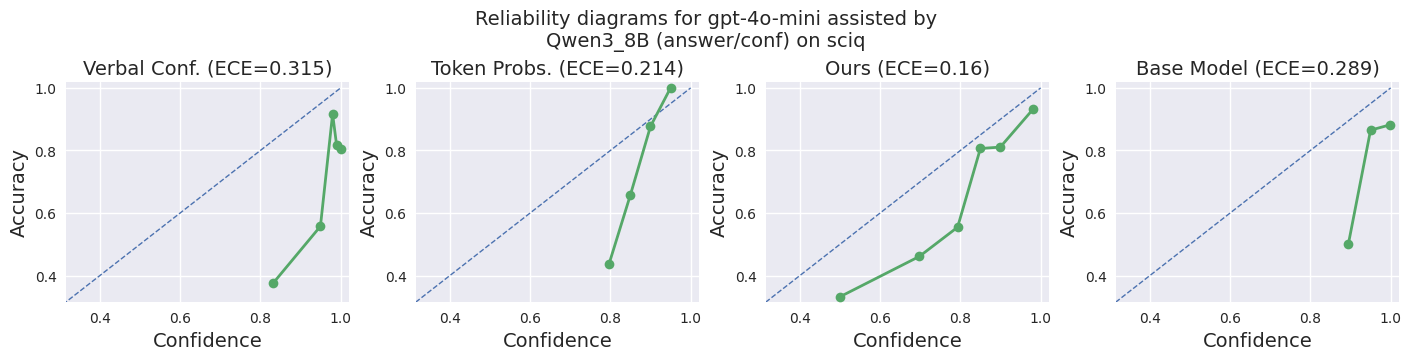

,Method,ECE1,ECE2,MCE,Brier,AUROC,DM_acc,OG_acc
0,vc,0.289967,0.315275,0.456250,0.291801,0.703825,0.661667,0.665
1,lp,0.185583,0.214249,0.360182,0.247615,0.661950,0.666667,0.665
2,ours,0.138967,0.160154,0.238323,0.219820,0.710352,0.661667,0.665


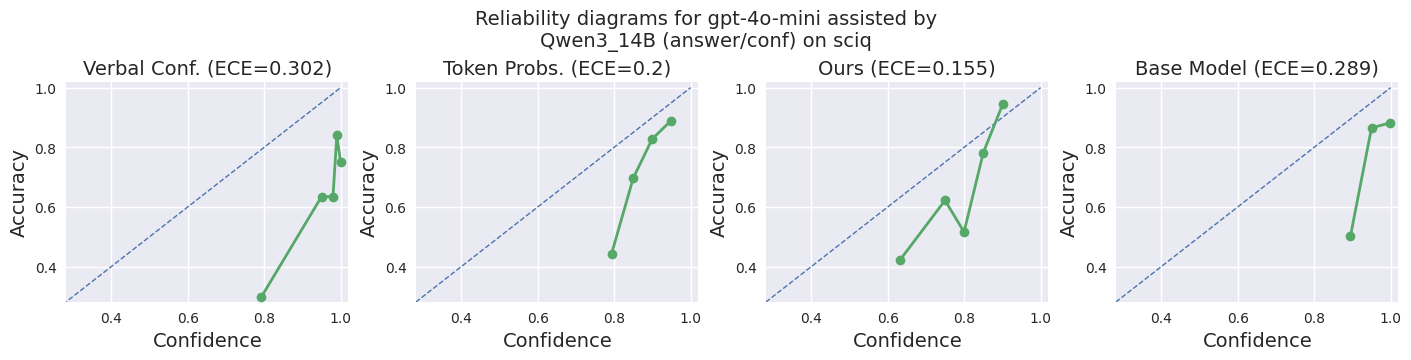

,Method,ECE1,ECE2,MCE,Brier,AUROC,DM_acc,OG_acc
0,vc,0.277533,0.301663,0.494643,0.281077,0.703440,0.670000,0.69
1,lp,0.172917,0.199867,0.350458,0.238256,0.665352,0.680000,0.69
2,ours,0.130050,0.155231,0.283297,0.219493,0.690190,0.673333,0.69



------------------------------------------------------------------------------------------------------------------------
*> Results <*



,Method,model,Acc,ECE1,ECE2,MCE,Brier,AUROC
0,vc,Qwen/Qwen3-0.6B,0.611684,0.335464,0.335873,0.350439,0.346580,0.558734
1,lp,Qwen/Qwen3-0.6B,0.640893,0.133333,0.163504,0.400000,0.232998,0.681805
2,ours,Qwen/Qwen3-0.6B,0.634021,0.043557,0.060538,0.100000,0.223192,0.632880
0,vc,Qwen/Qwen3-1.7B,0.631667,0.323633,0.342892,0.630000,0.329831,0.648318
1,lp,Qwen/Qwen3-1.7B,0.640000,0.217350,0.255322,0.472346,0.266550,0.689718


Baseline stats


,Acc,ECE1,ECE2,MCE,Brier,AUROC,model,Method
0,0.686,0.23629,0.274936,0.372147,0.260775,0.707194,baseline,baseline


In [7]:
models = [
    "Qwen/Qwen3-0.6B", 
    "Qwen/Qwen3-1.7B", 
    "Qwen/Qwen3-4B-Thinking-2507", 
    "Qwen/Qwen3-8B",
    "Qwen/Qwen3-14B", 
]

dataset = "sciq"

gpt_model_name = "gpt-4o-mini"

full_exp_df = []

for model in models:
    _, _, exp_df = get_output(model, gpt_model_name, dataset)
    full_exp_df.append(exp_df)
    
results_df = pd.concat(full_exp_df)

results_metrics = ["Acc", "ECE1", "ECE2", "MCE", "Brier", "AUROC"]

results_df["Acc"] = results_df["DM_acc"]
results_df = results_df[['Method', 'model']+results_metrics]

print("\n"+"----"*30)
print("*> Results <*\n")
display(results_df.head())

baseline_df = pd.read_csv("../outputs/baseline_stats.csv")
baseline_df.sort_values(by="dataset")

baseline_row = baseline_df[(baseline_df["dataset"] == dataset) & (baseline_df["model"] == gpt_model_name)][results_metrics].iloc[0]
baseline_row = dict(baseline_row)
baseline_row["model"] = "baseline"
baseline_row["Method"] = "baseline"
baseline_row = pd.DataFrame([baseline_row])

print("Baseline stats")
display(baseline_row)

results_df = pd.concat([results_df, baseline_row])

In [8]:
model_accs = {
    "Qwen/Qwen3-0.6B": 0.39175, 
    "Qwen/Qwen3-1.7B": 0.6, 
    "Qwen/Qwen3-4B-Thinking-2507": 0.64833, 
    "Qwen/Qwen3-8B": 0.65333,
    "Qwen/Qwen3-14B": 0.6933
}

METHODS_COLORS = {
    "vc": pal[2],
    "lp": pal[0],
    "ours": pal[3],
    "base_gpt": "k",
    "baseline": "k"
}

METHODS_MARKS = {
    "vc": "v",
    "lp": "^",
    "ours": "+",
    "base_gpt": "x",
    "baseline": "x"
}

METHODS_MARK_SIZES = {
    "vc": 150,
    "lp": 150,
    "ours": 300,
    "base_gpt": 175,
    "baseline": 175
}

METHODS_MARK_LWS = {
    "vc": 3,
    "lp": 3,
    "ours": 6,
    "base_gpt": 6,
    "baseline": 6
}

In [9]:
results_table = results_df[["Method", "model", "Acc", "ECE2", "MCE", "Brier"]]

avg_table = results_df[["Method", "Acc", "ECE2", "MCE", "Brier"]].groupby("Method").mean().reset_index()
avg_table["model"] = "Average"

full_table = pd.concat([results_table, avg_table])

full_table["Method"] = [METHODS_MAP[m] for m in full_table["Method"]]
full_table["model"] = [m.split("/")[-1] for m in full_table["model"]]


full_table

,Method,model,Acc,ECE2,MCE,Brier
0,Verbal Conf.,Qwen3-0.6B,0.611684,0.335873,0.350439,0.346580
1,Token Probs.,Qwen3-0.6B,0.640893,0.163504,0.400000,0.232998
2,Ours,Qwen3-0.6B,0.634021,0.060538,0.100000,0.223192
0,Verbal Conf.,Qwen3-1.7B,0.631667,0.342892,0.630000,0.329831
1,Token Probs.,Qwen3-1.7B,0.640000,0.255322,0.472346,0.266550
2,Ours,Qwen3-1.7B,0.643333,0.133931,0.202564,0.218546
0,Verbal Conf.,Qwen3-4B-Thinking-2507,0.653333,0.300222,0.476316,0.298758
1,Token Probs.,Qwen3-4B-Thinking-2507,0.666667,0.222191,0.404500,0.248709
2,Ours,Qwen3-4B-Thinking-2507,0.663333,0.119357,0.400000,0.209317
0,Verbal Conf.,Qwen3-8B,0.661667,0.315275,0.456250,0.291801


In [10]:
big_df = full_table
OUR_METHOD = "split_isotonic_on_ridge_nrt"

comp_methods = ["Token Probs.", "Verbal Conf.", "Ours", "Base Model"]

comp_methods_display = [m for m in comp_methods]
method_rank = {m: i for i, m in enumerate(comp_methods_display)}

big_df = (
    big_df.assign(_method_rank=big_df["Method"].map(method_rank))
          .sort_values(["model", "_method_rank"])
          .drop(columns="_method_rank")
          .reset_index(drop=True)
)
big_df = big_df[["model", "Method", "Acc", "ECE2", "MCE", "Brier"]]

print(big_df.to_latex(index=False, float_format="%.3f"))

\begin{tabular}{llrrrr}
\toprule
model & Method & Acc & ECE2 & MCE & Brier \\
\midrule
Average & Token Probs. & 0.659 & 0.211 & 0.397 & 0.247 \\
Average & Verbal Conf. & 0.646 & 0.319 & 0.482 & 0.310 \\
Average & Ours & 0.655 & 0.126 & 0.245 & 0.218 \\
Average & Base Model & 0.686 & 0.275 & 0.372 & 0.261 \\
Qwen3-0.6B & Token Probs. & 0.641 & 0.164 & 0.400 & 0.233 \\
Qwen3-0.6B & Verbal Conf. & 0.612 & 0.336 & 0.350 & 0.347 \\
Qwen3-0.6B & Ours & 0.634 & 0.061 & 0.100 & 0.223 \\
Qwen3-1.7B & Token Probs. & 0.640 & 0.255 & 0.472 & 0.267 \\
Qwen3-1.7B & Verbal Conf. & 0.632 & 0.343 & 0.630 & 0.330 \\
Qwen3-1.7B & Ours & 0.643 & 0.134 & 0.203 & 0.219 \\
Qwen3-14B & Token Probs. & 0.680 & 0.200 & 0.350 & 0.238 \\
Qwen3-14B & Verbal Conf. & 0.670 & 0.302 & 0.495 & 0.281 \\
Qwen3-14B & Ours & 0.673 & 0.155 & 0.283 & 0.219 \\
Qwen3-4B-Thinking-2507 & Token Probs. & 0.667 & 0.222 & 0.404 & 0.249 \\
Qwen3-4B-Thinking-2507 & Verbal Conf. & 0.653 & 0.300 & 0.476 & 0.299 \\
Qwen3-4B-Thinking-2507 

In [11]:
# print(full_table.to_latex(index=False, float_format="%.2f"))

In [12]:
def plot_method_frontiers(results_df, methods=None, n_bins=200000000):
    df = results_df.copy()
    if methods is None:
        methods = [m for m in df["Method"].unique()]

    fig, axs = plt.subplots(
        1, 2, figsize=(12, 3.5), 
        # constrained_layout=True
    )

    # panels = [("ECE2", "ECE2 (↓ better)"), ("Brier", "Brier (↓ better)")]
    panels = [("ECE2", "ECE2"), ("MCE", "MCE")]
    for ax, (ycol, ylabel) in zip(axs, panels):
        for method in methods:
            
            sub = df[df["Method"] == method].sort_values(by="Acc")

            ax.scatter(
                sub["Acc"], sub[ycol], 
                marker=METHODS_MARKS[method], 
                label=METHODS_MAP[method], 
                s=METHODS_MARK_SIZES[method], 
                lw=METHODS_MARK_LWS[method], 
                color=METHODS_COLORS[method]
            )

        ax.set_xlabel("Accuracy", fontsize=14)
        ax.set_ylabel(ylabel, fontsize=14)
        ax.grid(True, alpha=0.25)

    axs[1].legend(bbox_to_anchor=(0.97, 1), loc="upper left", fontsize=14)
    # axs[0].legend(loc="lower left", fontsize=14)
    plt.suptitle("Linguistic Calibration of Simulated Decisions", fontsize=16)
    fig.tight_layout()
    
    plt.savefig(f"../plots/sim_dec_frontier_{dataset}_{gpt_model_name}_by_model.png", dpi=600, bbox_inches="tight")
    
    plt.show()


In [13]:
# plot_method_frontiers(results_df, methods=["baseline", "lp", "vc", "ours"])

In [30]:
gpt_model_map = {
    "gpt-4o-mini": "GPT-4o-mini"
}
asst_method_map = {
    "vc": "GPT w/ VC",
    "lp": "GPT w/ TP",
    "ours": "GPT w/ Ours",
    "baseline": "GPT-4o-mini"
}


def plot_by_model(target_metric):
    fig, axs = plt.subplots(1, len(models), sharey=True, figsize=(3*len(models), 2.5))

    method_markers = {"baseline": "x"}
    
    for i, model in enumerate(models):
    
        ax = axs[i]
    
        model_df = results_df[results_df["model"] == model]
        baseline_acc = baseline_row["Acc"]
    
        ax.scatter(baseline_acc, baseline_row[target_metric], label=f"{gpt_model_map[gpt_model_name]}", marker="x", s=100, lw=5, color="k")
    
        for i in range(len(model_df)):
            
            row = model_df.iloc[i]
            row_method = row["Method"]
            if row_method == "ours":
                marker = "*"
            else:
                marker = "o"

            method_markers[row_method] = marker

            if row_method == "ours":
                s = 256
            else:
                s = 100
                
            ax.scatter(row["Acc"], row[target_metric], label=f"GPT w/ {asst_method_map[row_method]}", marker=marker, s=s, lw=1, color=METHODS_COLORS[row_method])
    
        model_name = model.split("/")[-1]
        if "Think" in model_name:
            model_name = model_name[:8]
        model_acc = model_accs[model]
        # ax.set_title(f"{model_name} (acc={round(model_acc, 3)})", fontsize=14)
        ax.set_title(f"{model_name}", fontsize=14)
        ax.set_xlabel("Accuracy (↑)", fontsize=14)
    
        ax.set_xlim(0.605, 0.69)
        if target_metric == "ECE2":
            ax.set_ylim(0.04, 0.375)
    
    axs[0].set_ylabel(f"{target_metric} (↓)", fontsize=14)
    # axs[-1].legend(loc="lower left", fontsize=11)

    methods=["baseline", "lp", "vc", "ours"]
    method_styles = {
        methods[0]: dict(color="k", lw=4.5, s=10),
        methods[1]: dict(color=pal[0], lw=1, s=12),
        methods[2]: dict(color=pal[2], lw=1, s=12),
        methods[3]: dict(color=pal[3], lw=1, s=16),
    }
    
    

    legend_handles = [
        Line2D(
            [0], [0],
            linestyle="None",
            marker=method_markers[m],
            markersize=method_styles[m]["s"],
            markerfacecolor=method_styles[m]["color"] if method_markers[m] != "x" else "none",
            markeredgecolor=method_styles[m]["color"],
            markeredgewidth=method_styles[m]["lw"],
            label=asst_method_map.get(m, m),
        )
        for m in methods
    ]
    
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=len(methods),
        frameon=False,
        fontsize=14,
        bbox_to_anchor=(0.5, -0.14),
    )
    
    # legend_handles = [
    #     Patch(
    #         facecolor=method_styles[m]["color"],
    #         label=asst_method_map.get(m, m),
    #     )
    #     for m in methods
    # ]

    # fig.legend(
    #     handles=legend_handles,
    #     loc="lower center",
    #     ncol=len(methods),
    #     frameon=False,
    #     fontsize=14,
    #     bbox_to_anchor=(0.5, -0.12),
    # )

    # fig.tight_layout(rect=[0, 0.08, 1, 1])  # leave space for bottom legend
        
    fig.tight_layout()
    plt.savefig(f"../plots/ling_cal_by_model_{target_metric}.png", dpi=600, bbox_inches="tight")
    plt.show()

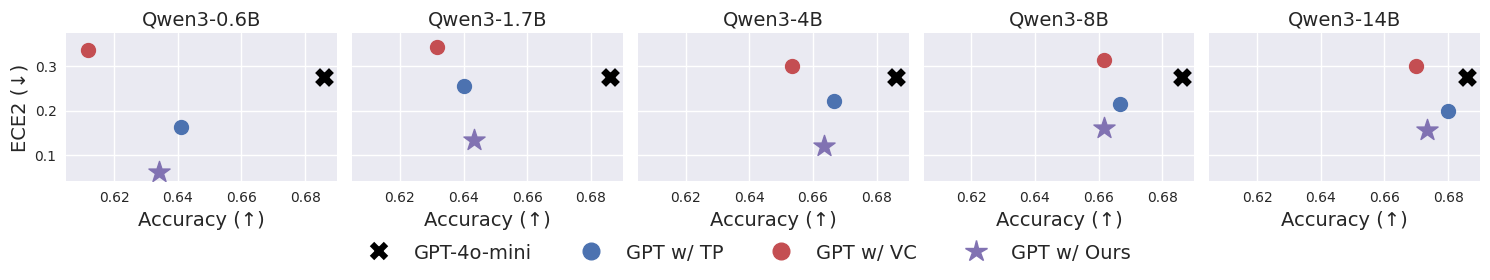

In [32]:
plot_by_model("ECE2")

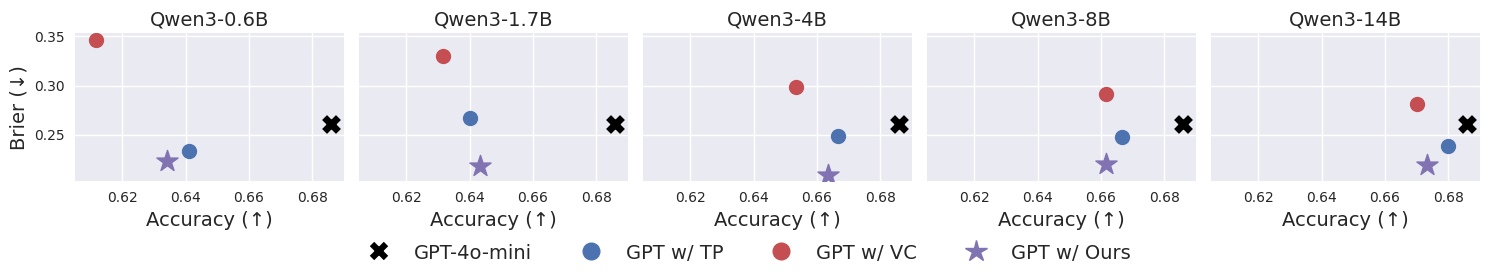

In [33]:
plot_by_model("Brier")

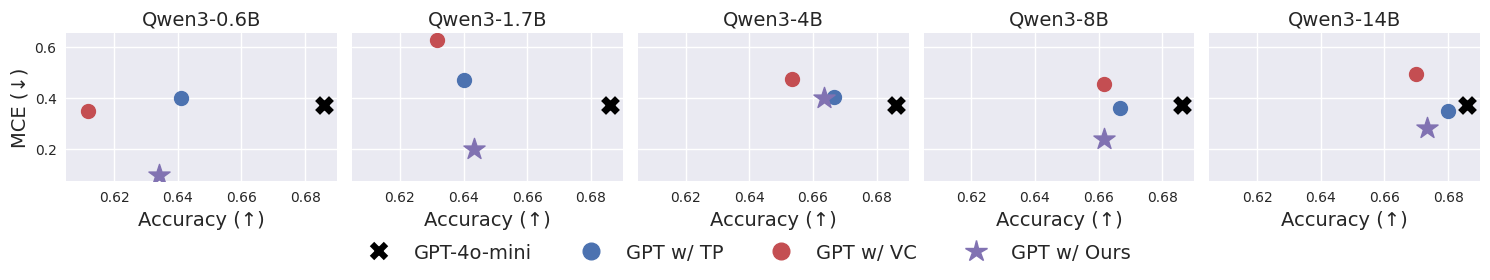

In [34]:
plot_by_model("MCE")